# Lecture 2 — Temporal synchrony

In [1]:
# Housekeeping code...
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display

# The notebook normally runs from lectures/. This fallback also supports a kernel
# launched from the repository root.
if Path("../media").exists():
    MEDIA = Path("../media")
    DATA = Path("../data/fireflies")
elif Path("media").exists():
    MEDIA = Path("media")
    DATA = Path("data/fireflies")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

FPS = 60
DURATION_S = 5 * 60
COLORS = {"June 3": "#4C78A8", "June 11": "#E45756"}
NIGHT_LABELS = {
    "June 3": "June 3 (low density)",
    "June 11": "June 11 (peak density)",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

def movie(filename, width=760):
    # Link local media without storing a second copy inside the notebook.
    return Video(
        str(MEDIA / filename),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

## In biological systems, *temporal synchronization* arrises at all scales

### 1. A crowd walking on a flexible bridge

[Millennium Bridge footage](https://www.youtube.com/watch?v=eAXVa__XWZ8); [Bocian *et al.* (2021)](https://doi.org/10.1038/s41467-021-27568-y).

In [2]:
movie("human-crowd-millennium-bridge-sway.mp4")

### 2. Courting male fiddler crabs

Source: [Reaney *et al.* (2008)](https://doi.org/10.1016/j.cub.2007.11.047), Movie S1.

In [3]:
movie("fiddler-crab-synchronous-waving.mp4")

### 3. Calcium and contraction in cardiac cells

Source: [Saraithong *et al.* (2025)](https://doi.org/10.1038/s42003-025-08162-0), Supplementary Movie 2.

In [4]:
movie("cardiomyocyte-monolayer-calcium-hd.mp4")

### 4. A firefly swarm

We will spend the next several lectures analyzing this data

Source: [Raphaël Sarfati et al., Self-organization in natural swarms of Photinus carolinus synchronous fireflies. Sci. Adv. (2021)](https://www.science.org/doi/10.1126/sciadv.abg9259)

Dataset: [Sarfati, Hayes, and Peleg (2023), Dryad](https://doi.org/10.5061/dryad.2547d7wvn).

In [5]:
movie("firefly-synchrony.mp4")

## Where does synchrony come from?

Possible mechanisms:

- An **external cue** drives everyone at once.
- A **leader** sets the timing.
- **Mutual coupling** lets units adjust to one another and synchrony *emerges*.
- The **initial conditions** produce matched timing without interaction.

> ### Demo
> 
> Here are the rules:
> 
> -  Keep you hands down.
> -  If you have the urge, quickly raise you hand and then lower it.
> -  If you see someone else raise their hand you have to do the same and then lower it.

### How could we test these ideas?

| Candidate origin | A decisive question or intervention |
| --- | --- |
| External cue | Does coordination persist when units receive different cues, or when the cue is removed/saturated? |
| Leader | What happens when the suspected leader is removed or altered? |
| Mutual coupling | Disrupt the coupling: vision, sound, touch, electrical contact  |
| Initial conditions | After setting matched or deliberately offset initial conditions, do isolated units retain the predicted timing relationship? Do they dephase over time? |

### How do systems use temporal synchronization?

| System | Proposed explanation |
| --- | --- |
| Fiddler crabs | Mate attraction: earliest waver gets the girl |
| Cardiomyocytes | Coordinated tissue activation and heart pumping |
| Fireflies | Mate attraction |
| Bridge crowd | A striking emergent collective motion, actually not so good ... |

> ### Discussion Question
>
> How do we *measure* synchrony?

## The biological clockwork of *Photinus carolinus*

<img src="../media/firefly-photinus-carolinus-closeup.jpg" width="600" style="display: block; margin: 0 auto;">

Flying males produce temporal light flash patterns and females can reply from near the ground.

Relevant timescales:

| Scale | Approximate duration |
| --- | ---: |
| One visible flash | 0.10–0.15 s |
| Separation of flashes within a train | 0.55 s |
| Collective flashing interval | 10 s |
| Recurrence of population bursts | 12 s |
| Display after sunset | 3 h |
| Peak season | ~ 2 weeks/yr |

Synchrony provides a species-specific signal to the female (other species can also be flashing). The dark interval gives the female a chance to respond. Of course, the males are all competing with each other ...

## Data acquisition

Summer recordings in Great Smoky Mountains National Park. The authors use *stereo imaging* to achieve 3D localization of flashes. 

- **Acquire:** two *synchronized* Sony $\alpha$ 7R IV cameras about 4 m apart; 60 fps, 1/60 s exposure, f/1.8, ISO 32,000, focus at infinity.
- **Calibrate space and time:** a 25 mm checkerboard at 5–10 positions; then a brief artificial light signal checked by cross-correlation.
- **Detect and reconstruct:** threshold bright pixels, match observations between views, triangulate 3D position, and filter impossible geometry.

About 60% of visible detections could be triangulated, and roughly 1% of obvious geometric outliers were removed.

### Stereo vision

<img src="../media/firefly-stereo-camera-geometry.png" width="800" style="display: block; margin: 0 auto;">

3D inference: Find the 3D point where the two rays intersect, within noise limits:

$$
\mathbf{X} \approx \mathbf{C}_1 + s_1\hat{\mathbf{r}}_1
             \approx \mathbf{C}_2 + s_2\hat{\mathbf{r}}_2.
$$

The shift of the flash between the two images is **parallax**. A wider camera separation generally makes depth easier to estimate, but shrinks the common field of view and can make matching harder.

![](../media/firefly-paper-figure-1-methods.png)

## The released data: one observation per row

Paper data was released on [Dryad](https://doi.org/10.5061/dryad.2547d7wvn) and is a series of headerless tables. 

Each row records 3D position and time (frame rate=60Hz) for one reconstructed detection. Here are the first 8 rows:

In [6]:
example_observations = pd.read_csv(
    DATA / "xyzt0611-class-window.csv",
    header=None,
    names=["x_m", "y_m", "z_m", "frame"],
)
example_observations.head(8)

,x_m,y_m,z_m,frame
0,-7.531038,22.892096,3.581177,129123
1,-7.525087,22.885565,3.583405,129124
2,0.261178,4.926277,0.538077,129124
3,-7.530197,22.902191,3.586181,129125
4,-1.176840,8.471946,1.422866,129125
5,0.260660,4.927213,0.537699,129125
6,-7.526875,22.898629,3.587569,129126
7,-1.177009,8.472198,1.422700,129126


In [7]:
movie("firefly-synchrony.mp4")

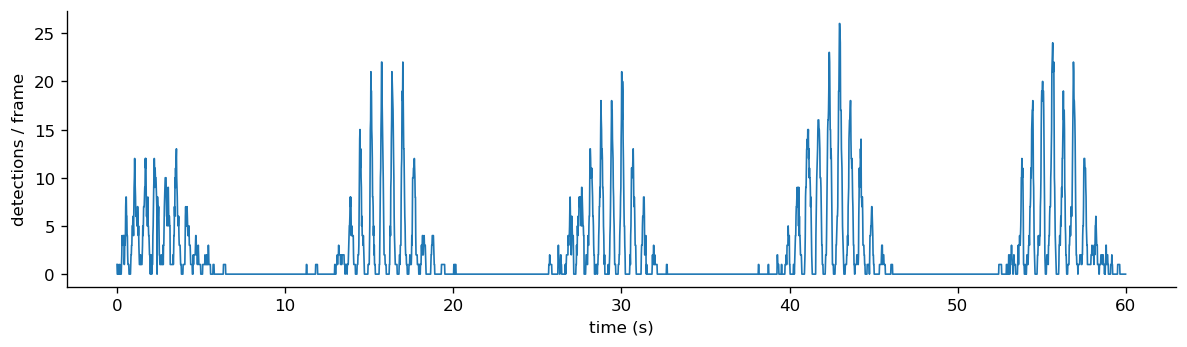

In [8]:
frames = np.arange(
    example_observations["frame"].min(),
    example_observations["frame"].max() + 1,
)
detections_per_frame = (
    example_observations.groupby("frame")
    .size()
    .reindex(frames, fill_value=0)
    .to_numpy()
)
time_s = (frames - frames[0]) / FPS

start_s = 231
show = (time_s >= start_s) & (time_s < start_s + 60)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s[show] - start_s, detections_per_frame[show], lw=1)
ax.set(xlabel="time (s)", ylabel="detections / frame")
fig.tight_layout()
plt.show()

The firefly season lasts about two weeks. How does activity change across the recording period?

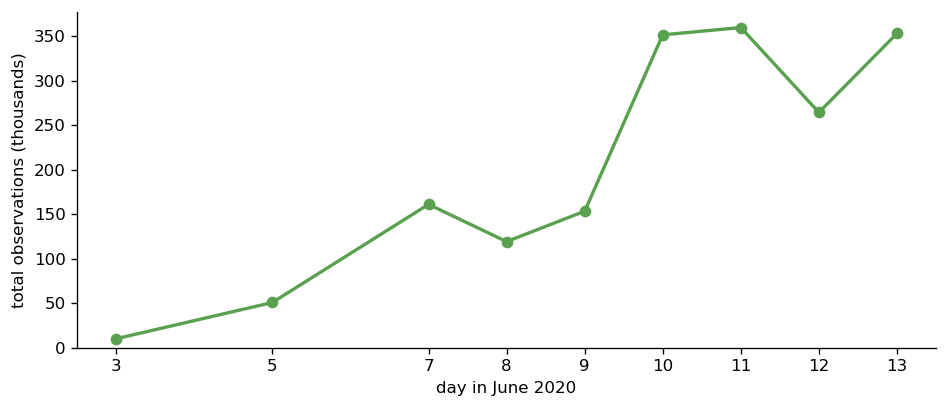

In [9]:
daily_totals = pd.read_csv(DATA / "daily-observation-counts.csv")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(
    daily_totals["day"],
    daily_totals["total_observations"] / 1000,
    "o-",
    lw=2,
    ms=6,
    color="#59A14F",
)
ax.set(
    xlabel="day in June 2020",
    ylabel="total observations (thousands)",
    xticks=daily_totals["day"],
)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

For the timing analyses below, we compare the busiest five-minute period on the lowest-activity day (June 3) and the peak day (June 11).

In [10]:
WINDOWS = {
    "June 3": {
        "file": "xyzt0603-class-window.csv",
        "start_frame": 317_172,
    },
    "June 11": {
        "file": "xyzt0611-class-window.csv",
        "start_frame": 129_112,
    },
}

def read_firefly_window(spec):
    df = pd.read_csv(
        DATA / spec["file"],
        header=None,
        names=["x_m", "y_m", "z_m", "frame"],
    )
    df["time_s"] = (df["frame"] - spec["start_frame"]) / FPS
    return df

fireflies = {
    night: read_firefly_window(spec)
    for night, spec in WINDOWS.items()
}

## Metric tournament

Now defend the proposed scalars. Test each one against four counterexamples:

1. many independent events at high density;
2. one external flash seen by everybody;
3. a duplicated or saturated camera detection; and
4. regular but staggered events with population-level periodicity.

Useful candidates include maximum count, variance, fraction of empty bins, peak width, recurrence, entropy, and excess same-bin pairs. A metric becomes scientific only when its question, event definition, resolution, and null are explicit.

## An honest anonymous-event raster

A conventional raster gives one identified individual to each row. We do not have identities. Instead, events that occur in the same frame are stacked vertically. Stack height is meaningful; vertical order is not.

We show the busiest 60 seconds inside each five-minute window to make the raw timing visible before binning.

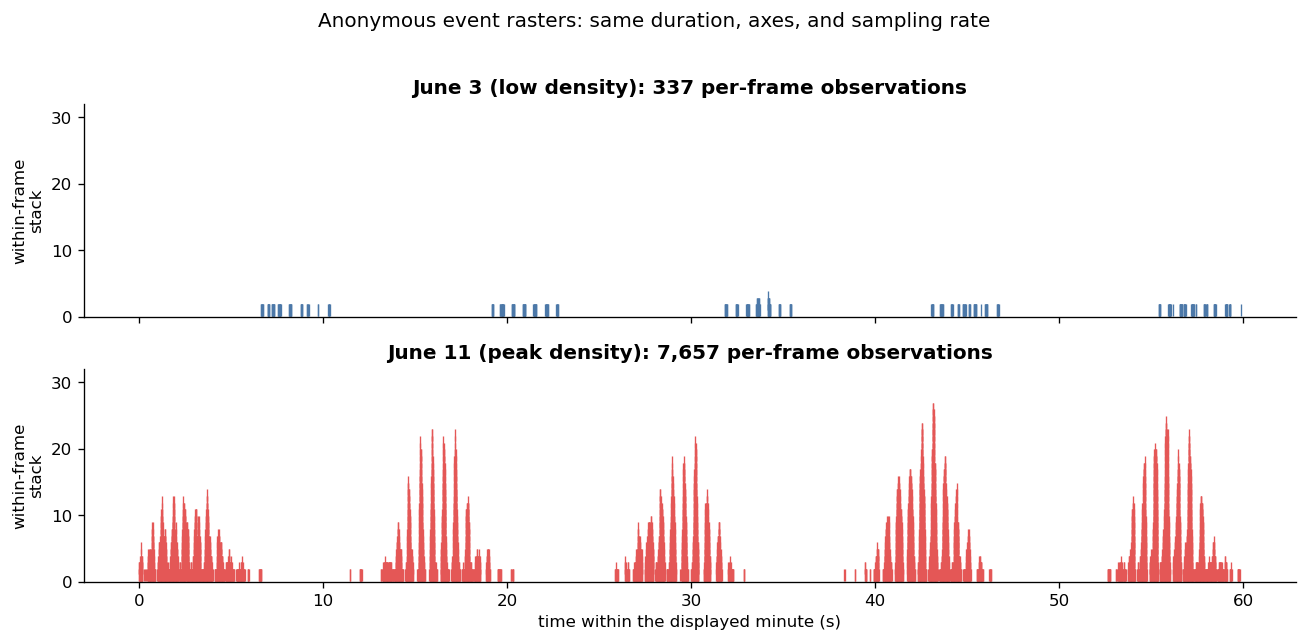

In [11]:
RASTER_START_S = {"June 3": 14, "June 11": 231}
RASTER_DURATION_S = 60

fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True, sharey=True)

for ax, (night, df) in zip(axes, fireflies.items()):
    start = RASTER_START_S[night]
    view = df.query("@start <= time_s < @start + @RASTER_DURATION_S").copy()
    view["within_frame_rank"] = view.groupby("frame").cumcount() + 1

    ax.scatter(
        view["time_s"] - start,
        view["within_frame_rank"],
        marker="|",
        s=45,
        linewidths=0.8,
        color=COLORS[night],
    )
    ax.set_title(f"{NIGHT_LABELS[night]}: {len(view):,} per-frame observations")
    ax.set_ylabel("within-frame\nstack")
    ax.set_ylim(0, 32)

axes[-1].set_xlabel("time within the displayed minute (s)")
fig.suptitle("Anonymous event rasters: same duration, axes, and sampling rate", y=1.02)
fig.tight_layout()
plt.show()

### Read the plot before interpreting it

- Both panels use the same duration, axes, and 60 fps acquisition.
- Empty time is data, not wasted space.
- A vertical stack means several reconstructed observations in one frame.
- Horizontal persistence can come from one biological flash remaining visible across frames.
- Nothing on the vertical axis identifies a firefly.

What does the raster establish? What does it still fail to establish?

## Binning defines “together”

Choose a bin width $\Delta t$ and count the observations in each bin:

$$
N_k(\Delta t)=\sum_i \mathbf{1}\!\left[k\Delta t \leq t_i < (k+1)\Delta t\right].
$$

At 60 fps, one frame is $1/60$ s. Our candidate widths—one frame, 0.05, 0.10, 0.50, and 1.0 s—ask different biological questions.

In [12]:
TOTAL_FRAMES = DURATION_S * FPS

def binned_counts(df, start_frame, bin_width_s):
    # Use integer camera frames so floating-point rounding cannot move boundaries.
    frames_per_bin = int(round(bin_width_s * FPS))
    if not np.isclose(frames_per_bin / FPS, bin_width_s):
        raise ValueError("Choose a bin width equal to a whole number of frames.")

    relative_frame = df["frame"].to_numpy() - start_frame
    bin_index = relative_frame // frames_per_bin
    n_bins = TOTAL_FRAMES // frames_per_bin
    counts = np.bincount(bin_index, minlength=n_bins)
    centers_s = (np.arange(n_bins) + 0.5) * frames_per_bin / FPS
    return centers_s, counts

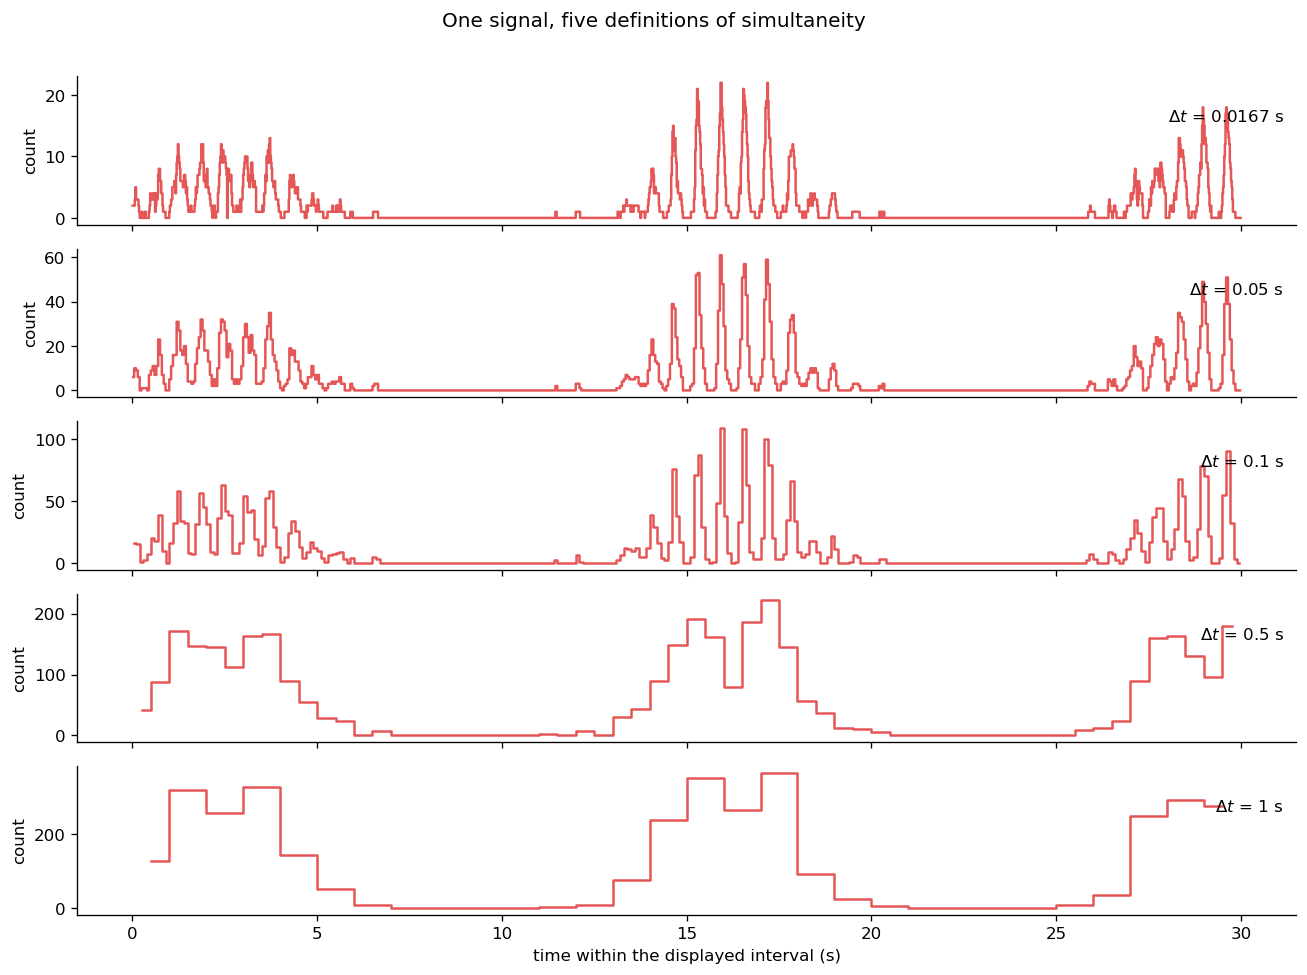

In [13]:
# The same 30 seconds of the peak night, viewed at five resolutions.
bin_widths_s = [1 / FPS, 0.05, 0.10, 0.50, 1.00]
example_start_s = RASTER_START_S["June 11"]
example_duration_s = 30

fig, axes = plt.subplots(len(bin_widths_s), 1, figsize=(11, 8), sharex=True)

for ax, dt in zip(axes, bin_widths_s):
    t, counts = binned_counts(
        fireflies["June 11"], WINDOWS["June 11"]["start_frame"], dt
    )
    keep = (t >= example_start_s) & (t < example_start_s + example_duration_s)
    ax.step(t[keep] - example_start_s, counts[keep], where="mid", color=COLORS["June 11"])
    ax.set_ylabel("count")
    ax.text(0.99, 0.78, f"$\\Delta t$ = {dt:.3g} s", transform=ax.transAxes,
            ha="right", va="top")

axes[-1].set_xlabel("time within the displayed interval (s)")
fig.suptitle("One signal, five definitions of simultaneity", y=1.01)
fig.tight_layout()
plt.show()

### Resolution is an analytical parameter

- **Too fine:** near-coincident events land in different bins; one flash occupies several adjacent frames.
- **Too coarse:** distinct flashes merge, peak heights grow, and temporal structure disappears.
- **Boundary sensitive:** shifting all bin edges by half a bin can split a burst differently.
- **Instrument limited:** timing finer than one camera frame cannot be recovered from these data.

A defensible result should report $\Delta t$ and survive reasonable nearby choices. The relevant biological time scales—not the prettiest plot—should guide the choice.

## Four count-based summaries

For $K$ bins with counts $N_k$:

1. **Mean activity** is a control, not synchrony:

   $$\mu=\langle N\rangle=\frac{1}{K}\sum_{k=1}^{K}N_k.$$

2. **Fano factor** asks whether fluctuations exceed a Poisson count with the same mean:

   $$F=\frac{\mathrm{Var}(N)}{\mu}. \qquad \text{Poisson expectation: } F=1$$

3. **Same-bin coincidence ratio** counts simultaneous pairs relative to independent Poisson events:

   $$g^{(2)}(0)=\frac{\langle N(N-1)\rangle}{\langle N\rangle^2}. \qquad \text{Poisson expectation: } g^{(2)}(0)=1$$

4. **Autocorrelation** asks whether high and low counts recur after a lag $\tau=\ell\Delta t$:

   $$C(\ell)=\frac{\langle (N_k-\mu)(N_{k+\ell}-\mu)\rangle}{\mathrm{Var}(N)}.$$

None of these numbers identifies a mechanism.

In [14]:
def count_metrics(counts):
    mean = counts.mean()
    return {
        "mean / frame": mean,
        "Fano factor": counts.var() / mean,
        "same-bin g2": np.mean(counts * (counts - 1)) / mean**2,
        "maximum / frame": counts.max(),
    }

frame_counts = {}
rows = []
for night, df in fireflies.items():
    _, counts = binned_counts(df, WINDOWS[night]["start_frame"], 1 / FPS)
    frame_counts[night] = counts
    rows.append({"night": night, **count_metrics(counts)})

metric_table = pd.DataFrame(rows).set_index("night").rename(index=NIGHT_LABELS)
metric_table.round(3)

,mean / frame,Fano factor,same-bin g2,maximum / frame
night,,,,
June 3 (low density),0.043,0.997,0.942,3
June 11 (peak density),1.596,7.297,4.946,30


June 3 is close to the one-frame Poisson expectations $F=1$ and $g^{(2)}(0)=1$. June 11 has similar instrumentation but much larger excess fluctuations and same-frame pairs.

This is evidence for strong temporal clustering of **observations** on June 11. It is not yet evidence for a particular interaction rule.

In [15]:
# A deliberately simple null: independent Poisson counts with the observed mean.
rng = np.random.default_rng(567)
null_rows = []

for night, observed in frame_counts.items():
    poisson = rng.poisson(observed.mean(), size=len(observed))
    null_rows.append({"series": f"{NIGHT_LABELS[night]} observed", **count_metrics(observed)})
    null_rows.append({"series": f"{NIGHT_LABELS[night]} Poisson", **count_metrics(poisson)})

pd.DataFrame(null_rows).set_index("series").round(3)

,mean / frame,Fano factor,same-bin g2,maximum / frame
series,,,,
June 3 (low density) observed,0.043,0.997,0.942,3
June 3 (low density) Poisson,0.044,0.999,0.981,2
June 11 (peak density) observed,1.596,7.297,4.946,30
June 11 (peak density) Poisson,1.587,0.994,0.996,9


The Poisson null is transparent, but biologically crude: one flash persists across several camera frames, and activity changes over the night. The empirical June 3 window is therefore an important companion control.

**A useful surprise:** if we repeat the calculation with 0.10 s bins, even June 3 looks strongly non-Poisson because a single biological flash fills much of one bin. Event definition and bin width can reverse the apparent verdict of a metric.

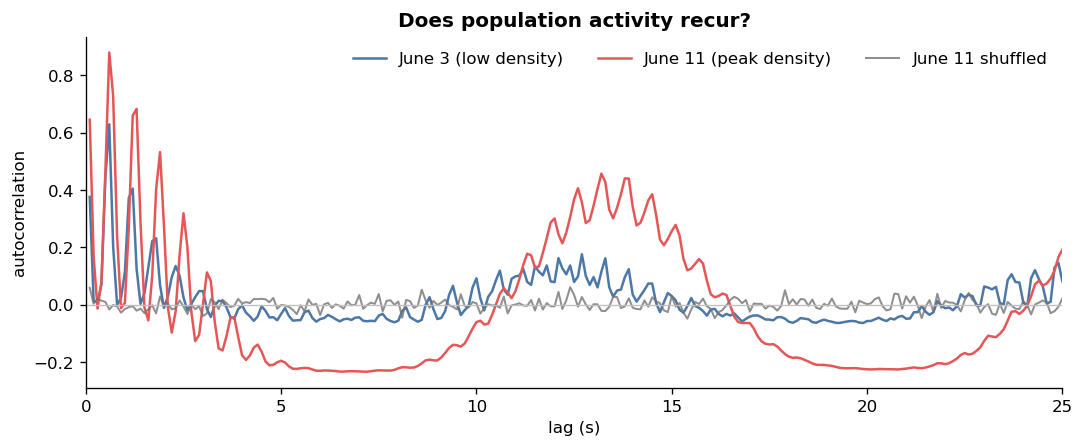

,peak C,lag_s
night,,
June 3 (low density),0.176,12.7
June 11 (peak density),0.457,13.2


In [16]:
def autocorrelation(counts, max_lag_bins):
    centered = counts - counts.mean()
    n = len(centered)
    raw = np.correlate(centered, centered, mode="full")[n - 1:n + max_lag_bins]
    overlap = np.arange(n, n - max_lag_bins - 1, -1)
    covariance = raw / overlap
    return covariance / covariance[0]

dt_s = 0.10
max_lag_s = 25
max_lag_bins = int(max_lag_s / dt_s)
acf = {}

for night, df in fireflies.items():
    _, counts = binned_counts(df, WINDOWS[night]["start_frame"], dt_s)
    acf[night] = autocorrelation(counts, max_lag_bins)

# Shuffling preserves the count distribution but destroys temporal recurrence.
high_counts = binned_counts(
    fireflies["June 11"], WINDOWS["June 11"]["start_frame"], dt_s
)[1]
acf["June 11 shuffled"] = autocorrelation(rng.permutation(high_counts), max_lag_bins)

lags_s = np.arange(max_lag_bins + 1) * dt_s
fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.plot(lags_s[1:], acf["June 3"][1:], label=NIGHT_LABELS["June 3"], color=COLORS["June 3"])
ax.plot(lags_s[1:], acf["June 11"][1:], label=NIGHT_LABELS["June 11"], color=COLORS["June 11"])
ax.plot(lags_s[1:], acf["June 11 shuffled"][1:], label="June 11 shuffled",
        color="0.45", linewidth=1.2, alpha=0.8)
ax.axhline(0, color="0.75", linewidth=0.8)
ax.set(xlabel="lag (s)", ylabel="autocorrelation", xlim=(0, max_lag_s),
       title="Does population activity recur?")
ax.legend(frameon=False, ncol=3)
plt.show()

recurrence_rows = []
search = (lags_s >= 5) & (lags_s <= 20)
for night in ["June 3", "June 11"]:
    lag = lags_s[search][np.argmax(acf[night][search])]
    peak = np.max(acf[night][search])
    recurrence_rows.append({"night": NIGHT_LABELS[night], "peak C": peak, "lag_s": lag})

pd.DataFrame(recurrence_rows).set_index("night").round(3)

June 11 shows recurrence near 13 s, close to the visible population-burst scale. Shuffling removes that temporal structure while preserving the histogram of counts.

But recurrence alone is periodicity, not proof of simultaneous events, interactions, or individual synchronization. An external cue or suitably matched initial conditions could also create it.

## Now reveal the paper's population-level answer

Only after constructing our own measures do we inspect Fig. 1E–H: nightly activity, representative low- and high-density count signals, and the authors' same-frame pair statistic across the density sweep.

**Nightly density and temporal clustering (Fig. 1E–H)**

![High-resolution Figure 1 panels E through H showing nightly activity, low- and high-density count signals, and fluctuation scaling](../media/firefly-paper-figure-1-results.png)

The paper uses all nights rather than only our two windows. Its pair-count scaling asks whether coincidence grows as expected for independent detections or becomes disproportionately large as density rises.

The figure and our calculations agree on the core observation: dense nights are not simply busier. Their activity is much more temporally clustered.

## What did we learn—and what did we not?

From anonymous event observations alone, we can support claims about:

- activity level;
- clustering and same-frame coincidence at a stated resolution; and
- recurrence of population-level activity.

We cannot yet determine:

- which fireflies adjust their timing;
- whether mutual coupling, an external cue, a leader, or initial conditions caused the pattern;
- whether the same individuals participate in successive bursts; or
- why natural selection favored the behavior.

Return to the four opening movies. Which claims could be tested with anonymous event times? Which require identities, perturbations, spatial information, or a different sensor?

## Exit ticket

In one minute, write:

1. one synchrony metric;
2. its null expectation;
3. the bin width or time resolution needed to interpret it; and
4. one biological conclusion that the metric cannot establish.

Next time we ask what can be learned when the timing of individual oscillators—not only population counts—matters.

## Sources

- Raphaël Sarfati, Julie C. Hayes, Elie Sarfati, and Orit Peleg, [“Spatio-temporal reconstruction of emergent flash synchronization in firefly swarms via stereoscopic 360-degree cameras”](https://doi.org/10.1098/rsif.2020.0179), *Journal of the Royal Society Interface* 17 (2020).
- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [“Self-organization in natural swarms of *Photinus carolinus* synchronous fireflies”](https://doi.org/10.1126/sciadv.abg9259), *Science Advances* 7 (2021).
- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [3D time-resolved flash-occurrence dataset](https://doi.org/10.5061/dryad.2547d7wvn), Dryad (2023).